In [11]:
import os
import math
import gc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset
from dotenv import load_dotenv
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    default_data_collator,
    TrainerCallback,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel


In [12]:
class LossHistoryCallback(TrainerCallback):
    def __init__(self):
        self.steps = []
        self.losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            self.steps.append(state.global_step)
            self.losses.append(logs["loss"])

loss_cb = LossHistoryCallback()

In [13]:
print("allocated GB:", torch.cuda.memory_allocated() / 1024**3)
print("reserved  GB:", torch.cuda.memory_reserved() / 1024**3)

allocated GB: 0.0
reserved  GB: 0.046875


In [14]:
load_dotenv()

hf_token = os.getenv("HF_TOKEN")
print("HF_TOKEN loaded:", bool(hf_token))


HF_TOKEN loaded: True


In [15]:
df = pd.read_csv("qa_with_context.csv")
df


,row_idx,question,gt_surah,gt_verses,hit,hit_rank,hit_doc_meta,retrieved_docs_meta,hit_doc_text,retrieved_docs_text,answer_en
0,0,What is the only book that is free from any do...,2,"[1, 2]",True,2.0,"{'ayah_end': 2.0, 'ayah_start': 2.0, 'surah_no...","[{'ayah_end': 2.0, 'ayah_start': 2.0, 'surah_n...",ayah: this is the book! there is no doubt abou...,"[""ayah: the revelation of this book is-beyond ...",Answer: This is the Book of Allah . The eviden...
1,1,Are the fruits of paradise similar to the frui...,2,[25],True,5.0,"{'ayah_end': 25.0, 'ayah_start': 25.0, 'surah_...","[{'ayah_end': 42.0, 'ayah_start': 42.0, 'surah...",ayah: give good news ˹o prophet˺ to those who ...,['ayah: and any fruit they desire.\ntafseer: a...,"Answer: Yes, and the evidence: 'And give good ..."
2,2,How many deaths and how many lives do humans h...,2,[28],False,NaN,NaN,"[{'ayah_end': 2.0, 'ayah_start': 2.0, 'surah_n...",NaN,"['ayah: surely humanity is in ˹grave˺ loss,\nt...",Answer: Not Found\nEvidence: NONE
3,3,How many heavens are there?,2,[29],True,7.0,"{'ayah_end': 29.0, 'ayah_start': 29.0, 'surah_...","[{'ayah_end': 15.0, 'ayah_start': 15.0, 'surah...",ayah: he is the one who created everything in ...,['ayah: do you not see how allah created seven...,Answer: He it is Who created for you all that ...
4,4,"What did Adam learn from Allah , which was no...",2,[31],True,2.0,"{'ayah_end': 31.0, 'ayah_start': 31.0, 'surah_...","[{'ayah_end': 33.0, 'ayah_start': 33.0, 'surah...","ayah: he taught adam the names of all things, ...","['ayah: allah said, ""o adam! inform them of th...",Answer: He taught Adam the names of all things...
...,...,...,...,...,...,...,...,...,...,...,...
1186,1186,Who is the wife of Ibrahim who laughed when s...,11,[71],True,1.0,"{'ayah_end': 71.0, 'ayah_start': 71.0, 'surah_...","[{'ayah_end': 71.0, 'ayah_start': 71.0, 'surah...","ayah: and his wife was standing by, so she lau...","[""ayah: and his wife was standing by, so she l...",Answer: She is Sarah.\nEvidence: [11 : 71 - 71...
1187,1187,"Indeed, Abraham was forbearing, often turning ...",11,[75],True,1.0,"{'ayah_end': 75.0, 'ayah_start': 75.0, 'surah_...","[{'ayah_end': 75.0, 'ayah_start': 75.0, 'surah...","ayah: truly, abraham was forbearing, tender-he...","[""ayah: truly, abraham was forbearing, tender-...","Answer: Abraham, peace be upon him, is patient..."
1188,1188,Why did Lot grieve when the guests arrived at...,11,[77],True,2.0,"{'ayah_end': 77.0, 'ayah_start': 77.0, 'surah_...","[{'ayah_end': 68.0, 'ayah_start': 68.0, 'surah...","ayah: when our messenger-angels came to lot, h...","['ayah: lot pleaded, ""indeed, these are my gue...",Answer: He feared for them because they were h...
1189,1189,"What does Lut mean by his statement, 'If only...",11,[80],True,1.0,"{'ayah_end': 80.0, 'ayah_start': 80.0, 'surah_...","[{'ayah_end': 80.0, 'ayah_start': 80.0, 'surah...","ayah: he responded, ""if only i had the strengt...","['ayah: he responded, ""if only i had the stren...",Answer: If I had power and supporters among yo...


In [16]:
sys_prompt = """You are a retrieval-grounded Quran QA assistant (English). You MUST answer using ONLY the provided retrieved context. The retrieved context may include Qur'an translation text and Tafsir (e.g., Tafsir al-Jalalayn). Treat the context as the ONLY source of truth.

Rules (strict):
1) Do NOT use outside knowledge, memory, or guesses. If the answer is not explicitly supported by the retrieved context, say you do not have enough evidence to answer.
2) Do NOT invent verse numbers, surah names, citations, quotes, or details.
3) Every factual claim about what the Qur'an says or what a story contains MUST be supported by at least one citation from the retrieved context.
4) If the user asks “What did Allah say about X?”, only state what is present in the retrieved context and cite the surah/ayah range. Do NOT paraphrase as a direct quote unless it is clearly a Qur'an translation line in the context. If it is tafsir, label it as tafsir explanation (not a direct Qur'an quote).
5) If retrieved passages are ambiguous or contradictory, explicitly say so and present both views with citations.
6) Keep the tone respectful and neutral. Avoid issuing fatwas or absolute rulings. If the question requires scholarly/legal judgment beyond the context, say so.
7) If the context is insufficient: output "INSUFFICIENT_CONTEXT" and provide 3–7 suggested retrieval keywords/queries that would likely fetch the missing evidence (names, key terms, story elements, concepts). Do NOT answer from guessing.

Output format:
- Answer: (concise, 2–6 sentences max)
- Evidence: bullet list. Each bullet includes: a short support statement + citation in the format (Surah X Ayah A-B).
- Explanation (optional): 2–6 sentences, only if it is supported by context; cite if you add new info.

"""

In [17]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

train_df_lora, val_df_lora = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    shuffle=True,
)

print("Train:", len(train_df_lora), "Val:", len(val_df_lora), "Test:", len(test_df))


Train: 856 Val: 96 Test: 239


In [18]:

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [19]:
# IMPORTANT: use a raw string on Windows to avoid escape issues
BASE_MODEL = r"C:\models\Llama-3.2-3B-Instruct"  # <-- change if needed

tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL,
    use_fast=True,
    token=hf_token,
    local_files_only=True,  # set False if you want HF to download
)

# Llama tokenizers often have no pad token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def make_chat_text(row):
    user_content = (
        f"Question:\n{row['question']}\n\n"
        f"Context:\n{row['retrieved_docs_meta']}\n\n"
        "Answer using ONLY the context."
    )

    messages = [
        {"role": "system", "content": sys_prompt},
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": str(row["answer_en"])},
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    ).strip()

    # Ensure EOS at the end
    if tokenizer.eos_token and not text.endswith(tokenizer.eos_token):
        text += tokenizer.eos_token

    return text


In [20]:
train_texts = [make_chat_text(r) for r in train_df_lora.to_dict("records")]
val_texts   = [make_chat_text(r) for r in val_df_lora.to_dict("records")]

train_ds = Dataset.from_dict({"text": train_texts})
val_ds   = Dataset.from_dict({"text": val_texts})

print("num samples train:", len(train_ds))
print("num samples val:", len(val_ds))


num samples train: 856
num samples val: 96


In [21]:
MAX_LEN = 2048

def tokenize_batch(batch):
    enc = tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
    )

    # ignore padding tokens in loss
    labels = []
    for ids, mask in zip(enc["input_ids"], enc["attention_mask"]):
        labels.append([tok if m == 1 else -100 for tok, m in zip(ids, mask)])

    enc["labels"] = labels
    return enc

train_tok = train_ds.map(tokenize_batch, batched=True, remove_columns=train_ds.column_names)
val_tok   = val_ds.map(tokenize_batch, batched=True, remove_columns=val_ds.column_names)

cols = ["input_ids", "attention_mask", "labels"]
train_tok.set_format(type="torch", columns=cols)
val_tok.set_format(type="torch", columns=cols)

print("Tokenized. Example input_ids length:", len(train_tok[0]["input_ids"]))


Map:   0%|          | 0/856 [00:00<?, ? examples/s]

Map:   0%|          | 0/96 [00:00<?, ? examples/s]

Tokenized. Example input_ids length: 2048


In [22]:
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Compute capability:", torch.cuda.get_device_capability(0))
    print("BF16 supported:", torch.cuda.is_bf16_supported())

print("allocated GB:", torch.cuda.memory_allocated() / 1024**3)
print("reserved  GB:", torch.cuda.memory_reserved() / 1024**3)


torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Compute capability: (8, 9)
BF16 supported: True
allocated GB: 0.0
reserved  GB: 0.0


In [23]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
)

model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id

# Optional: reduces memory during training
model.gradient_checkpointing_enable()


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [24]:
print("allocated GB:", torch.cuda.memory_allocated() / 1024**3)
print("reserved  GB:", torch.cuda.memory_reserved() / 1024**3)

allocated GB: 2.088771343231201
reserved  GB: 2.888671875


In [25]:
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 12,156,928 || all params: 3,224,906,752 || trainable%: 0.3770


In [26]:
print("allocated GB:", torch.cuda.memory_allocated() / 1024**3)
print("reserved  GB:", torch.cuda.memory_reserved() / 1024**3)

allocated GB: 2.869248867034912
reserved  GB: 4.40234375


In [27]:
OUT_DIR = "./qlora_llama32_quran"
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

steps_per_epoch = math.ceil(891 / (1 * 16))
max_steps = steps_per_epoch

args = TrainingArguments(
    output_dir=OUT_DIR,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,

    max_steps=max_steps,
    num_train_epochs=1,
    learning_rate=3e-5,

    logging_strategy="steps",
    logging_steps=1,

    eval_strategy="steps",
    eval_steps=10,
    per_device_eval_batch_size=1,
    prediction_loss_only=True,
    eval_accumulation_steps=1,

    save_steps=200,
    report_to="none",
    remove_unused_columns=False,
    bf16=use_bf16,
    fp16=(torch.cuda.is_available() and not use_bf16),
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=default_data_collator,
    callbacks=[loss_cb],
)


In [28]:
#validation loss befor training
metrics_before = trainer.evaluate()
print("BEFORE eval_loss:", metrics_before.get("eval_loss"))

BEFORE eval_loss: 2.2383873462677


In [29]:
#train 1 epoch
trainer.train()

C:\Users\LOQ\Documents\GitHub\PythonProject3\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Model Preparation Time
10,2.043800,1.998019,0.012800
20,1.820100,1.855170,0.012800
30,1.771400,1.746391,0.012800
40,1.664800,1.656293,0.012800
50,1.545600,1.597804,0.012800


TrainOutput(global_step=56, training_loss=1.827890817608152, metrics={'train_runtime': 3693.4481, 'train_samples_per_second': 0.243, 'train_steps_per_second': 0.015, 'total_flos': 3.089010322833408e+16, 'train_loss': 1.827890817608152, 'epoch': 1.0373831775700935})

In [30]:
#validation loss after training
metrics_after = trainer.evaluate()
print("AFTER  eval_loss:", metrics_after.get("eval_loss"))

AFTER  eval_loss: 1.5856596231460571


In [31]:
trainer.save_model(OUT_DIR)
print("Saved LoRA adapter to:", OUT_DIR)

Saved LoRA adapter to: ./qlora_llama32_quran


In [32]:
# Train loss per step (from your callback)
print("Train loss points:", len(loss_cb.steps))
print("Last train loss:", (loss_cb.steps[-1], loss_cb.losses[-1]))

# Eval loss every 10 steps (from Trainer log_history)
eval_logs = [x for x in trainer.state.log_history if "eval_loss" in x]
print("Eval loss points:", len(eval_logs))
print([(x["step"], x["eval_loss"]) for x in eval_logs])

Train loss points: 56
Last train loss: (56, 1.6362)
Eval loss points: 6
[(10, 1.9980192184448242), (20, 1.8551701307296753), (30, 1.7463911771774292), (40, 1.656293272972107), (50, 1.5978039503097534), (56, 1.5856596231460571)]


Train points: 56 Eval points: 7


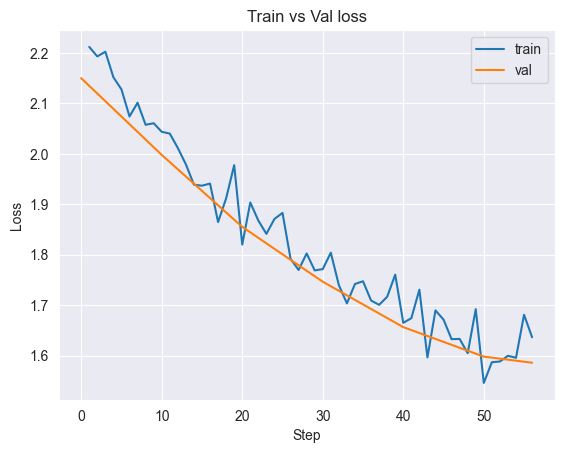

In [33]:
train_steps = loss_cb.steps
train_losses = loss_cb.losses
baseline_eval_loss = 2.1501524448394775
eval_logs = [x for x in trainer.state.log_history if "eval_loss" in x]
eval_steps = [0] + [x["step"] for x in eval_logs]
eval_losses = [baseline_eval_loss] + [x["eval_loss"] for x in eval_logs]

print("Train points:", len(train_steps), "Eval points:", len(eval_steps))

plt.figure()
plt.plot(train_steps, train_losses, label="train")
plt.plot(eval_steps, eval_losses, label="val")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Train vs Val loss")
plt.legend()
plt.show()

In [34]:
ADAPTER_DIR = OUT_DIR

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    token=hf_token,
    local_files_only=True,
)
base_model.config.use_cache = False
base_model.config.pad_token_id = tokenizer.pad_token_id

reloaded = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
reloaded.eval()

tmp_args = TrainingArguments(
    output_dir="./tmp_eval",
    per_device_eval_batch_size=1,
    report_to="none",
    remove_unused_columns=False,
    bf16=use_bf16,
    fp16=(torch.cuda.is_available() and not use_bf16),
)
tmp_trainer = Trainer(
    model=reloaded,
    args=tmp_args,
    eval_dataset=val_tok,
    data_collator=default_data_collator,
)
print(tmp_trainer.evaluate())


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

{'eval_loss': 1.5855554342269897, 'eval_model_preparation_time': 0.0089, 'eval_runtime': 131.0389, 'eval_samples_per_second': 0.733, 'eval_steps_per_second': 0.733}


In [35]:
LORA_DIR   = "./qlora_llama32_quran"
OUT_MERGED = "./llama32_quran_merged_hf"

dtype = torch.float16

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=True)

base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=dtype,
    device_map=None,
    low_cpu_mem_usage=False,
)

model = PeftModel.from_pretrained(base, LORA_DIR)

model = model.merge_and_unload()

model.save_pretrained(OUT_MERGED, safe_serialization=True)
tokenizer.save_pretrained(OUT_MERGED)

print("Saved merged model to:", OUT_MERGED)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Saved merged model to: ./llama32_quran_merged_hf


In [19]:
del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print(torch.cuda.memory_allocated()/1024**3, "GB allocated")
    print(torch.cuda.memory_reserved()/1024**3, "GB reserved")


14.807482242584229 GB allocated
16.646484375 GB reserved
